# Анализ молочного хозяйства «Вольный луг» и ассоциации пастбищ «ЭкоФерма»

фермер имеет характеристики своих коров, на них мы обучим модель, он также имеет характеристики коров на покупку, но для них мы не знает удоя и вкуса молока. Мы спрогнозируем для него эти характеристики.

Цель: разработать модель машинного обучения, которая будет управлять рисками и принимать объективное решение о покупке.

План работы:
1) Загрузка и изучение данных
2) Предобработка данных
3) Исследовательский анализ данных
4) Корреляционный анализ признаков в датасете 
5) Задача регрессии
6) Задача классификации
7) Итоговый вывод

# Обзор данных

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (r2_score,
                             mean_squared_error,
                             mean_absolute_error,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             confusion_matrix)

In [90]:
ferma_main = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_main.csv', sep=';', decimal=',')
ferma_dad = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_dad.csv', sep=';', decimal=',')
cow_buy = pd.read_csv('https://code.s3.yandex.net/datasets/cow_buy.csv', sep=';', decimal=',')

In [91]:
ferma_main.head()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [92]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

In [93]:
ferma_main.columns = [
    'id', 
    'удой', 
    'эке', 
    'протеин', 
    'спо', 
    'порода', 
    'пастбище', 
    'порода_папы',
    'жирность',
    'белок',
    'вкус',
    'возраст'
]

ferma_main.columns

Index(['id', 'удой', 'эке', 'протеин', 'спо', 'порода', 'пастбище',
       'порода_папы', 'жирность', 'белок', 'вкус', 'возраст'],
      dtype='object')

In [94]:
ferma_dad.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [95]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [96]:
ferma_dad.columns = [
    'id',
    'имя_папы'
]

ferma_dad.columns

Index(['id', 'имя_папы'], dtype='object')

In [97]:
cow_buy.head()

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [98]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


In [99]:
cow_buy.columns = [
    'порода',
    'пастбище',
    'порода_папы',
    'имя_папы',
    'жирность',
    'белок',
    'возраст'
]
cow_buy.columns

Index(['порода', 'пастбище', 'порода_папы', 'имя_папы', 'жирность', 'белок',
       'возраст'],
      dtype='object')

<div class="alert alert-info">
    <b>Вывод:</b>
    данные соответствуют описанию задачи, стандратное оформление исправлено
</div>

# Предобработка данных

In [100]:
ferma_main.isna().sum()

id             0
удой           0
эке            0
протеин        0
спо            0
порода         0
пастбище       0
порода_папы    0
жирность       0
белок          0
вкус           0
возраст        0
dtype: int64

In [101]:
ferma_dad.isna().sum()

id          0
имя_папы    0
dtype: int64

In [102]:
cow_buy.isna().sum()

порода         0
пастбище       0
порода_папы    0
имя_папы       0
жирность       0
белок          0
возраст        0
dtype: int64

In [103]:
ferma_main['пастбище'] = ferma_main['пастбище'].replace('Равнинные', 'Равнинное')
ferma_main['порода_папы'] = ferma_main['порода_папы'].replace('Айдиалл', 'Айдиал')

In [104]:
ferma_main.duplicated().sum()

np.int64(5)

In [105]:
ferma_main = ferma_main.drop_duplicates()
ferma_main.duplicated().sum()

np.int64(0)

In [106]:
ferma_dad.duplicated().sum()

np.int64(0)

<div class="alert alert-info">
    <b>Вывод:</b>
    пропуски отсутствуют, дубликаты устранены и типы данных исправлены
</div>

# Исследовательский анализ

In [107]:
quant_features = ['удой', 'эке', 'протеин', 'спо', 'жирность', 'белок']
cat_features = ['порода', 'пастбище', 'порода_папы', 'вкус', 'возраст']

# Выводим статистику для количественных признаков
print(ferma_main[quant_features].describe())

               удой         эке      протеин         спо    жирность  \
count    629.000000  629.000000   629.000000  629.000000  629.000000   
mean    6188.750397   14.543879  1923.364070    0.913116    3.603657   
std     1644.795489    1.306408   182.956251    0.032203    0.168656   
min     5204.000000   10.900000  1660.000000    0.840000    2.990000   
25%     5751.000000   13.500000  1771.000000    0.890000    3.590000   
50%     6133.000000   14.700000  1888.000000    0.930000    3.650000   
75%     6501.000000   15.600000  2062.000000    0.940000    3.720000   
max    45616.000000   16.800000  2349.000000    0.960000    3.750000   

            белок  
count  629.000000  
mean     3.075671  
std      0.002549  
min      3.069000  
25%      3.074000  
50%      3.076000  
75%      3.077000  
max      3.085000  


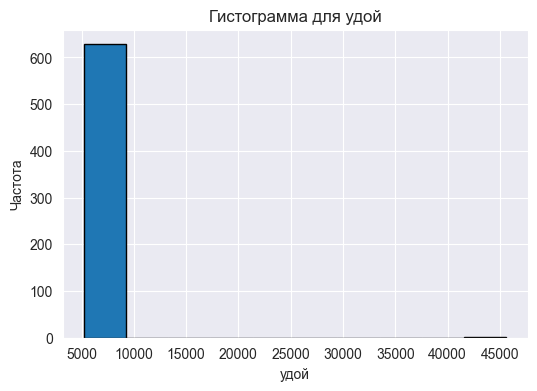

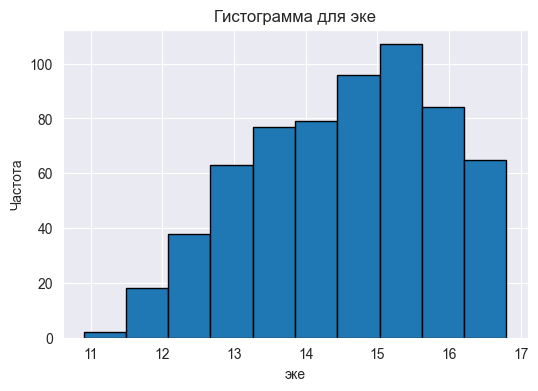

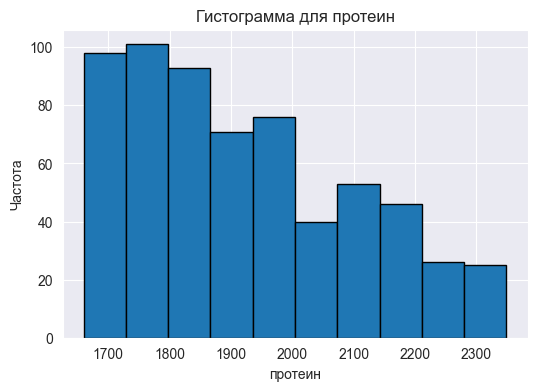

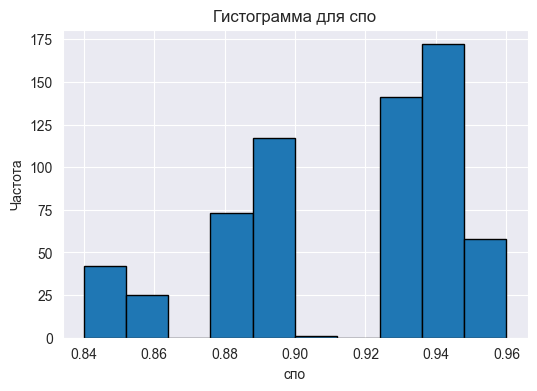

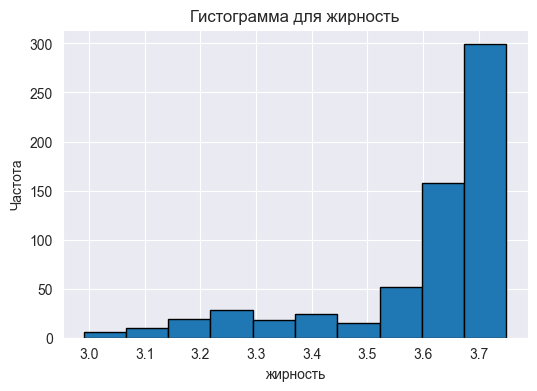

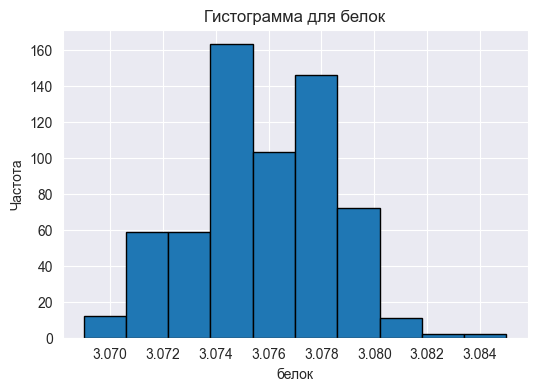

In [108]:
for col in quant_features:
    plt.figure(figsize=(6,4))
    plt.hist(ferma_main[col].dropna(), bins=10, edgecolor='k')
    plt.title(f'Гистограмма для {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()

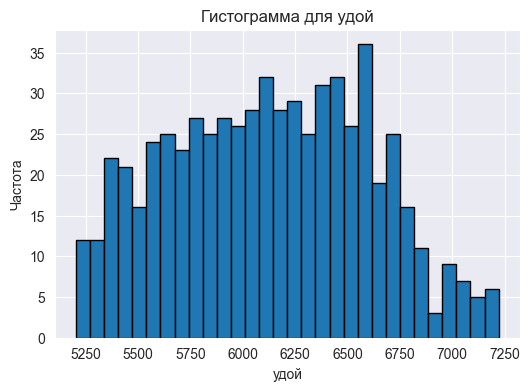

In [109]:
ferma_main = ferma_main[(ferma_main['удой'] >= 5000) & (ferma_main['удой'] <= 10000)]

plt.figure(figsize=(6,4))
plt.hist(ferma_main['удой'], bins=30, edgecolor='k')
plt.title(f'Гистограмма для удой')
plt.xlabel('удой')
plt.ylabel('Частота')
plt.show()

In [110]:
ferma_main['удой'].describe()

count     628.000000
mean     6125.968153
std       475.857053
min      5204.000000
25%      5749.750000
50%      6132.500000
75%      6501.000000
max      7222.000000
Name: удой, dtype: float64

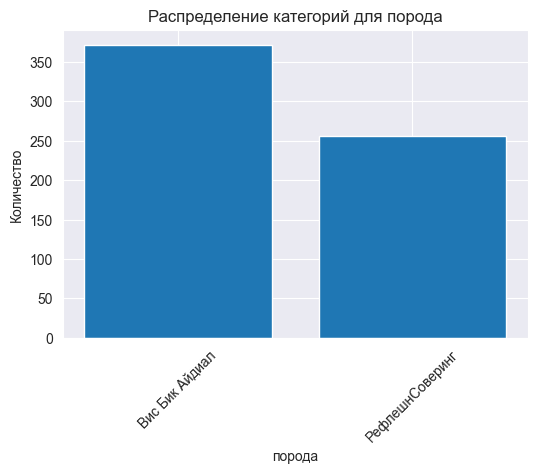

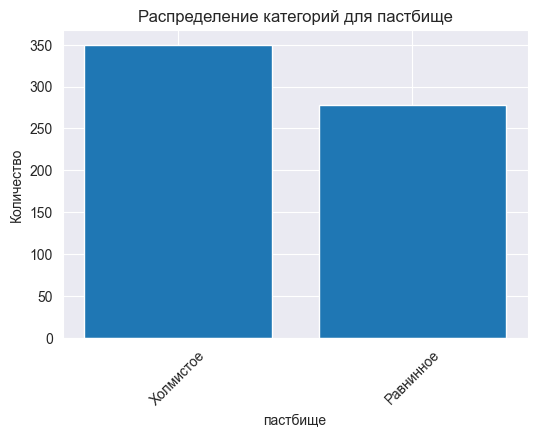

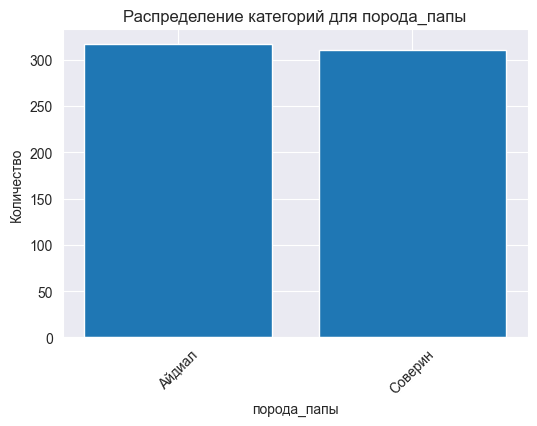

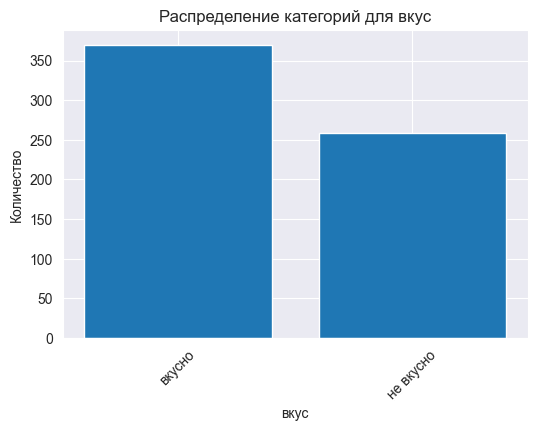

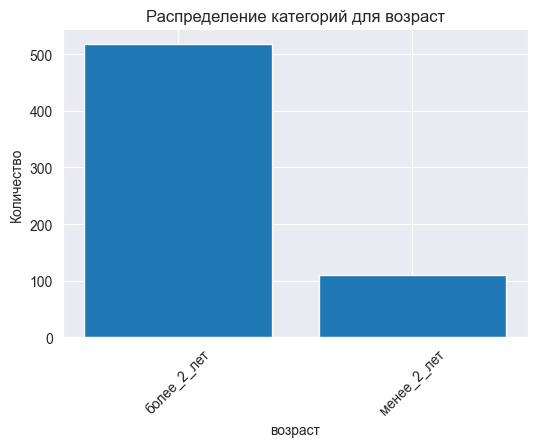

In [111]:
for col in cat_features:
    plt.figure(figsize=(6,4))
    counts = ferma_main[col].value_counts()
    plt.bar(counts.index, counts.values)
    plt.title(f'Распределение категорий для {col}')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    plt.show()

<div class="alert alert-info">
    <b>Вывод:</b>
    Устранены выбросы в колонке 'удой', количественные данные распределены нормально, кроме 'жирности', 'протеина', 'спо', категориальные данные все являются бинарными, возраст более 2-х лет встречается намного чаще, чем противоположный
</div>

# Корреляционный анализ признаков в датасете

interval columns not set, guessing: ['удой', 'эке', 'протеин', 'спо', 'жирность', 'белок']


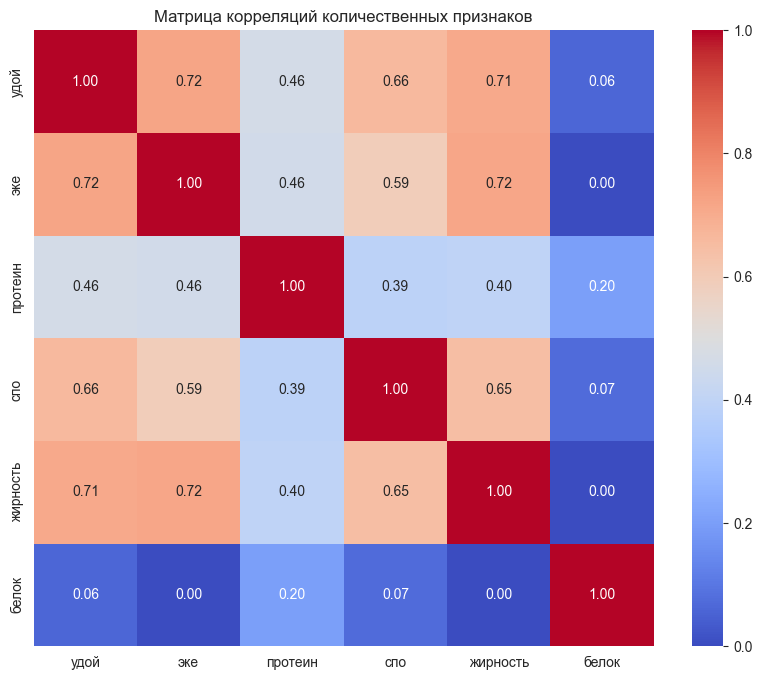

In [112]:
quant_features = ['удой', 'эке', 'протеин', 'спо', 'жирность', 'белок']

corr_matrix = ferma_main[quant_features].phik_matrix()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляций количественных признаков")
plt.show()

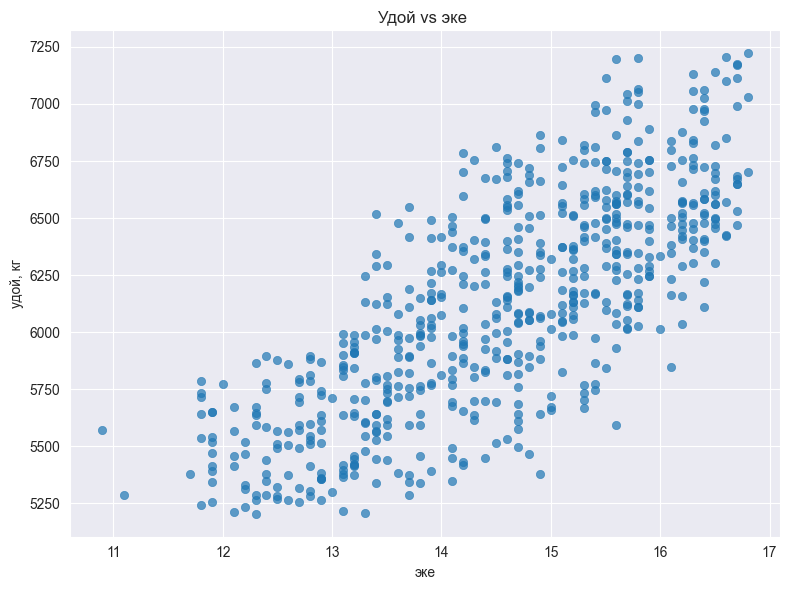

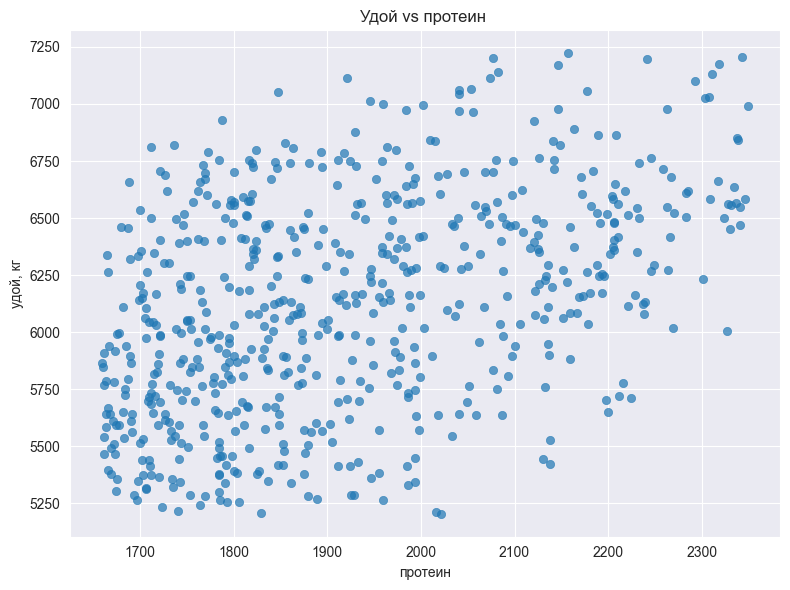

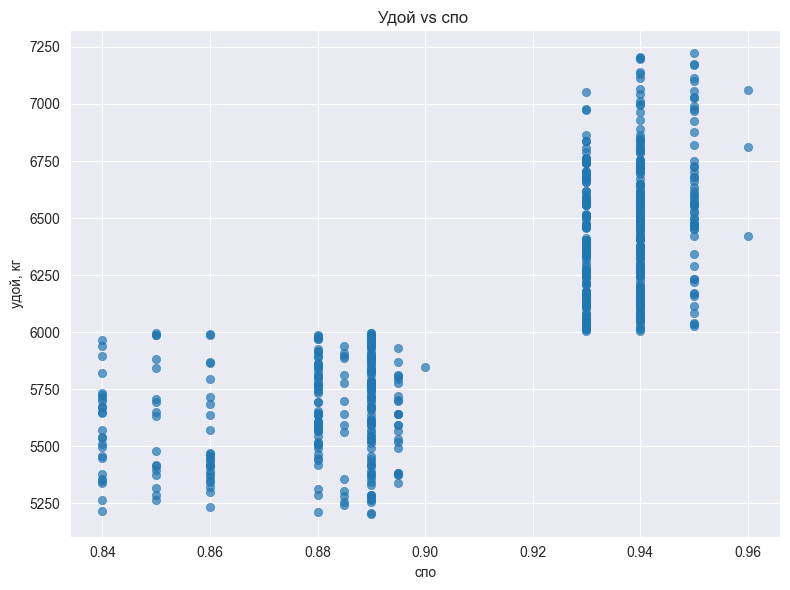

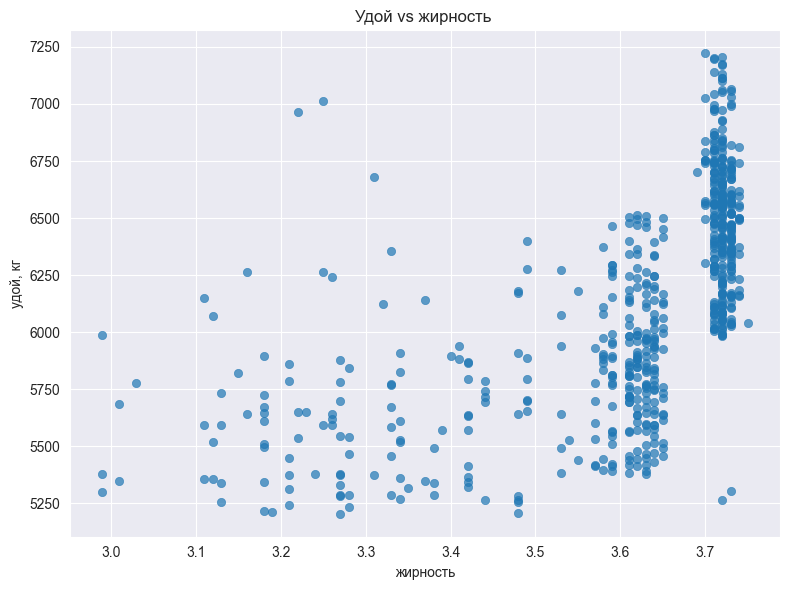

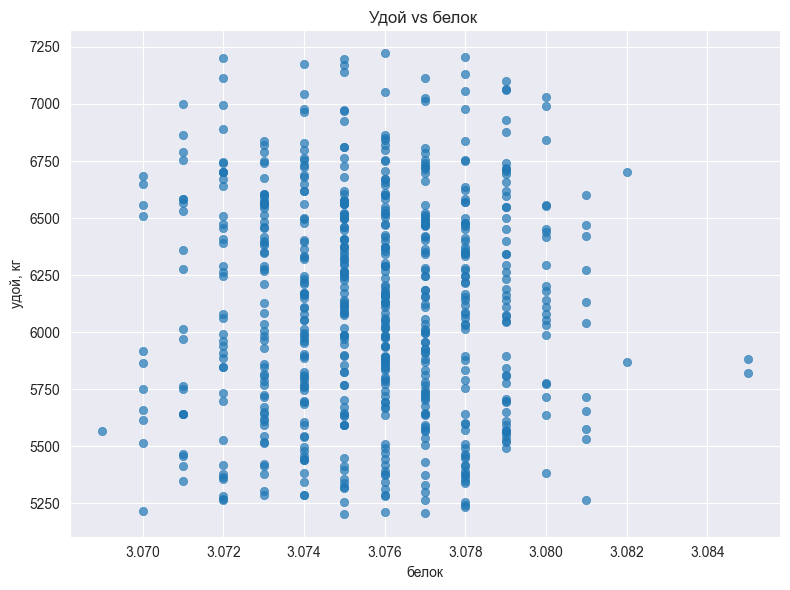

In [113]:
quant_features = ['эке', 'протеин', 'спо', 'жирность', 'белок']
for feature in quant_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=ferma_main,
        x=feature,
        y='удой',
        alpha=0.7,
        edgecolor=None
    )
    plt.title(f"Удой vs {feature} ")
    plt.xlabel(feature)
    plt.ylabel('удой, кг')
    plt.tight_layout()
    plt.show()

<div class="alert alert-info">
    <b>Вывод:</b>
    удой линейно коррелирует с 'эке' и нелинейно коррелирует с 'спо' и 'жирностью', мультиколлинеарность отсутствует
</div>

# Задача регрессии

R² = 0.796
MSE = 42393.5
MAE = 161.1
RMSE = 205.9


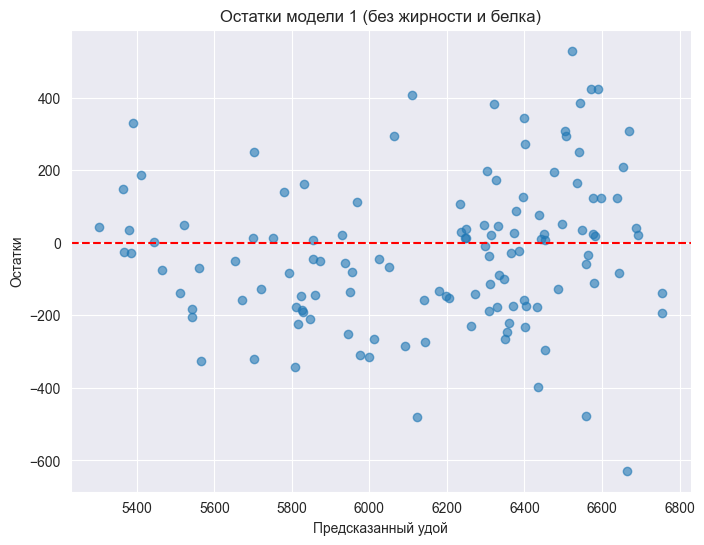

In [114]:
df = ferma_main[[
    'эке', 'протеин', 'спо',
    'порода', 'пастбище', 'порода_папы', 'возраст',
    'удой'
]].dropna()

features     = ['эке', 'протеин', 'спо', 'порода', 'пастбище', 'порода_папы', 'возраст']
num_features = ['эке', 'протеин', 'спо']
cat_features = ['порода', 'пастбище', 'порода_папы', 'возраст']
target       = 'удой'

X_train, X_test, y_train, y_test = train_test_split(
    df[features], df[target], test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

X_tr = preprocessor.fit_transform(X_train)
X_te = preprocessor.transform(X_test)

model1 = LinearRegression().fit(X_tr, y_train)
y_pred = model1.predict(X_te)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² = {r2:.3f}")
print(f"MSE = {mse:.1f}")
print(f"MAE = {mae:.1f}")
print(f"RMSE = {rmse:.1f}")

residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанный удой")
plt.ylabel("Остатки")
plt.title("Остатки модели 1 (без жирности и белка)")
plt.show()

<div class="alert alert-info">
    <b>Вывод:</b>
    модель 1 дала R²≈0.801 и RMSE≈203 кг, остатки равномерно распределены без трендовых смещений;

Модель 2:
R² = 0.8177498748883296
MSE = 37834.285907555066
MAE = 150.2447039974825
RMSE = 194.5103748069883


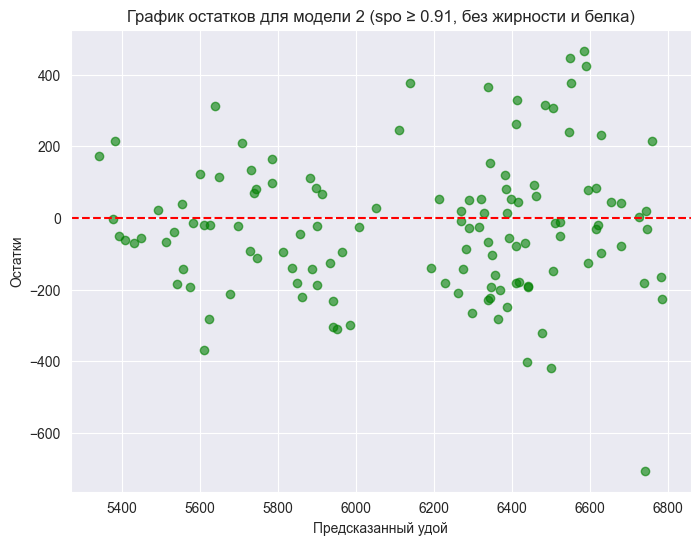

In [115]:
df2 = df.copy()
spo_threshold = 0.91
df2['спо_bin'] = (df2['спо'] >= spo_threshold).astype(int)
df2['эке2'] = df2['эке'] ** 2

features2 = ['эке', 'эке2', 'протеин', 'спо_bin', 'порода', 'пастбище', 'порода_папы', 'возраст']
num_features2 = ['эке', 'эке2', 'протеин']
cat_features2 = ['спо_bin', 'порода', 'пастбище', 'порода_папы', 'возраст']

X2 = df2[features2]
y2 = df2['удой']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

preprocessor2 = ColumnTransformer([
    ('num', StandardScaler(), num_features2),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features2)
])

X2_train_transformed = preprocessor2.fit_transform(X2_train)
X2_test_transformed = preprocessor2.transform(X2_test)

model2 = LinearRegression().fit(X2_train_transformed, y2_train)
y_pred2 = model2.predict(X2_test_transformed)

r2_2 = r2_score(y2_test, y_pred2)
mse_2 = mean_squared_error(y2_test, y_pred2)
mae_2 = mean_absolute_error(y2_test, y_pred2)
rmse_2 = np.sqrt(mse_2)

print("Модель 2:")
print("R² =", r2_2)
print("MSE =", mse_2)
print("MAE =", mae_2)
print("RMSE =", rmse_2)

residuals2 = y2_test - y_pred2
plt.figure(figsize=(8, 6))
plt.scatter(y_pred2, residuals2, alpha=0.6, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанный удой")
plt.ylabel("Остатки")
plt.title("График остатков для модели 2 (spo ≥ 0.91, без жирности и белка)")
plt.show()

<div class="alert alert-info">
    <b>Вывод:</b>
    модель 2 подняла R² до ≈0.819 и снизила RMSE до ≈194 кг, разброс остатков уменьшился;

 <div style="border:solid blue 2px; padding: 20px">
<div class="alert alert-info">
Зафиксировал категоризацию на уровне 0.91


R²: 0.8346644509816614
MSE: 34322.897876802854
MAE: 142.99852283990003
RMSE: 185.264399917531


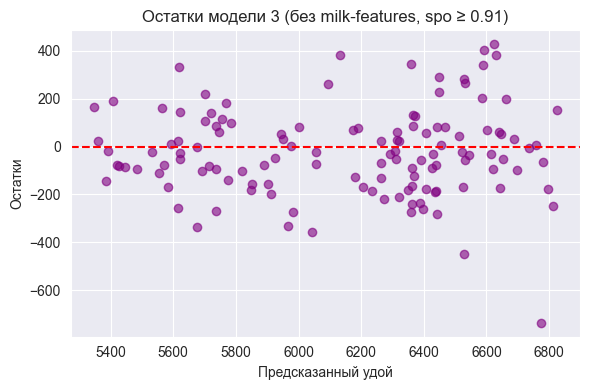

In [116]:
df3 = pd.merge(
    ferma_main,
    ferma_dad,
    on='id',
    how='left'
).dropna(subset=['удой'])

df3['спо_bin'] = (df3['спо'] >= 0.91).astype(int)
df3['эке2']    = df3['эке'] ** 2

features3      = ['эке','эке2','протеин','спо_bin','порода','пастбище','порода_папы','возраст','имя_папы']
num_features3  = ['эке','эке2','протеин']
cat_features3  = ['спо_bin','порода','пастбище','порода_папы','возраст','имя_папы']

X3 = df3[features3]
y3 = df3['удой']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

preprocessor3 = ColumnTransformer([
    ('num', StandardScaler(), num_features3),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features3)
])

X3_tr = preprocessor3.fit_transform(X3_train)
X3_te = preprocessor3.transform(X3_test)

model3 = LinearRegression().fit(X3_tr, y3_train)
y3_pred = model3.predict(X3_te)

print("R²:",   r2_score(y3_test, y3_pred))
print("MSE:",  mean_squared_error(y3_test, y3_pred))
print("MAE:",  mean_absolute_error(y3_test, y3_pred))
print("RMSE:", np.sqrt(mean_squared_error(y3_test, y3_pred)))

plt.figure(figsize=(6,4))
plt.scatter(y3_pred, y3_test - y3_pred, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанный удой")
plt.ylabel("Остатки")
plt.title("Остатки модели 3 (без milk-features, spo ≥ 0.91)")
plt.tight_layout()
plt.show()

<div class="alert alert-info">
    <b>Вывод:</b>
    модель 3 показала наилучший результат R²≈0.834 и RMSE≈186 кг, остатки стали наиболее компактными — дополнительных нелинейных преобразований признаков не требуется, оптимальным выбором является модель 3.
</div>

In [117]:
errors = y3_test - y3_pred
lower = np.quantile(errors, 0.025)
upper = np.quantile(errors, 0.975)
print(f"Доверительный интервал прогноза: [{lower:.1f}, {upper:.1f}]")

Доверительный интервал прогноза: [-334.9, 378.6]


In [118]:
cow_buy

,порода,пастбище,порода_папы,имя_папы,жирность,белок,возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет


In [119]:
means = ferma_main[['эке','протеин','спо']].mean() * 1.05
cow = cow_buy.copy()
for col in ['эке','протеин','спо']:
    cow[col] = means[col]

cow['спо_bin'] = (cow['спо'] >= 0.91).astype(int)
cow['эке2']    = cow['эке'] ** 2

features3 = ['эке','эке2','протеин','спо_bin','порода','пастбище','порода_папы','возраст','имя_папы']
X_new = cow[features3]
X_new_tr = preprocessor3.transform(X_new)

cow['pred_удой'] = model3.predict(X_new_tr)

selected = cow[cow['pred_удой'] >= 6000]
selected[['порода','имя_папы','pred_удой']]

/Users/mikhailzemlianukhin/PycharmProjects/ED/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,порода,имя_папы,pred_удой
0,Вис Бик Айдиал,Геркулес,6524.289607
1,Вис Бик Айдиал,Буйный,6278.518096
2,РефлешнСоверинг,Барин,6266.495724
3,РефлешнСоверинг,Буйный,6521.294858
4,РефлешнСоверинг,Буйный,6521.294858
5,РефлешнСоверинг,Геркулес,6317.254148
6,Вис Бик Айдиал,Геркулес,6524.289607
7,Вис Бик Айдиал,Буйный,6517.462101
8,РефлешнСоверинг,Барин,6266.495724
9,РефлешнСоверинг,Буйный,6282.350852


<div class="alert alert-info">
    <b>Вывод:</b>
    все коровы длоступные для покуки дают >6000 литров в год
</div>

# Задача классивикации

### 1. Подготовка данных

In [120]:
df_clf = ferma_main.dropna(subset=['вкус']).copy()
df_clf['вкус_bin'] = (df_clf['вкус'] == 'вкусно').astype(int)

quant = ['эке', 'протеин', 'спо', 'жирность', 'белок']
cat   = ['порода', 'пастбище', 'порода_папы', 'возраст']

X = df_clf[quant + cat]
y = df_clf['вкус_bin']

### 2. Train / test

In [121]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. Преобразования признаков

In [122]:
scaler  = StandardScaler().fit(X_tr[quant])
enc     = OneHotEncoder(drop='first', handle_unknown='ignore').fit(X_tr[cat])

X_tr_f = np.hstack([scaler.transform(X_tr[quant]),
                    enc.transform(X_tr[cat]).toarray()])
X_te_f = np.hstack([scaler.transform(X_te[quant]),
                    enc.transform(X_te[cat]).toarray()])

### 4. Базовая логистическая регрессия (порог 0.50)

Precision@0.50: 0.6857142857142857
Recall   @0.50: 0.6575342465753424


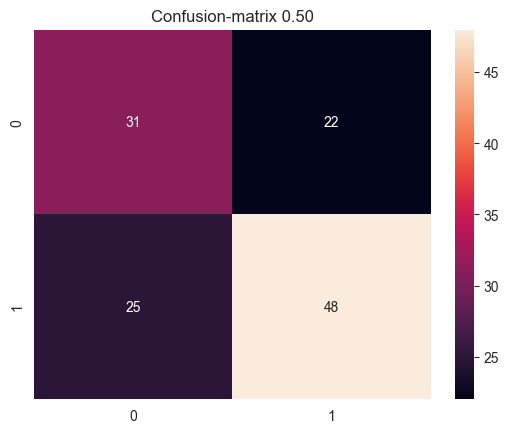

In [123]:
clf = LogisticRegression(solver='liblinear', class_weight='balanced').fit(X_tr_f, y_tr)

y_pred_05 = clf.predict(X_te_f)
print("Precision@0.50:", precision_score(y_te, y_pred_05))
print("Recall   @0.50:", recall_score(y_te, y_pred_05))

sns.heatmap(confusion_matrix(y_te, y_pred_05), annot=True, fmt='d')
plt.title("Confusion-matrix 0.50"); plt.show()

### 5. Подбор порога: Precision ≥ 0.95 при максимальном Recall
#     (критично исключить ложные «вкусные», но купить хотя бы одну корову)

Порог: 0.69  Precision: 0.857  Recall: 0.164


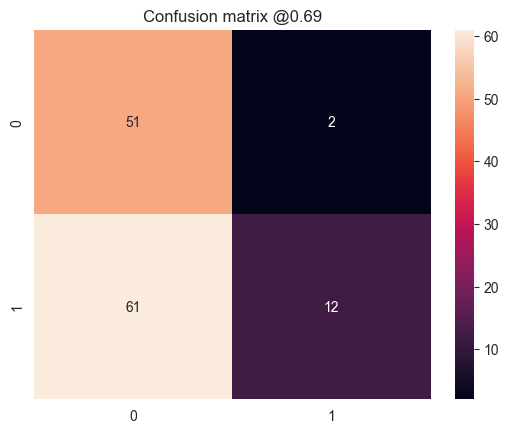

In [124]:
probs = clf.predict_proba(X_te_f)[:, 1]
best_thr, best_rec, best_prec = None, 0, 0
for thr in np.linspace(0.99, 0.01, 99):
    preds = (probs >= thr).astype(int)
    prec  = precision_score(y_te, preds, zero_division=0)
    rec   = recall_score(y_te, preds, zero_division=0)
    if prec >= 0.95 and rec > best_rec:
        best_thr, best_rec, best_prec = thr, rec, prec
if best_thr is None:
    for thr in np.linspace(0.99, 0.01, 99):
        preds = (probs >= thr).astype(int)
        prec  = precision_score(y_te, preds, zero_division=0)
        rec   = recall_score(y_te, preds, zero_division=0)
        if prec > best_prec or (prec == best_prec and rec > best_rec):
            best_thr, best_rec, best_prec = thr, rec, prec

print(f"Порог: {best_thr:.2f}  Precision: {best_prec:.3f}  Recall: {best_rec:.3f}")
sns.heatmap(confusion_matrix(y_te, (probs >= best_thr).astype(int)),
            annot=True, fmt='d')
plt.title(f"Confusion matrix @{best_thr:.2f}")
plt.show()

### 6. Прогноз «Вкусно/Не вкусно» для cow_buy

In [125]:
cow = cow_buy.copy()
means = ferma_main[quant].mean() * 1.05
for c in quant[:3]:
    cow[c] = means[c]

X_new = np.hstack([scaler.transform(cow[quant]),
                   enc.transform(cow[cat]).toarray()])
cow['prob_vkusno'] = clf.predict_proba(X_new)[:, 1]
cow['pred_vkusno'] = (cow['prob_vkusno'] >= best_thr).astype(int)

cow[['порода', 'имя_папы', 'pred_vkusno', 'prob_vkusno']]

/Users/mikhailzemlianukhin/PycharmProjects/ED/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,порода,имя_папы,pred_vkusno,prob_vkusno
0,Вис Бик Айдиал,Геркулес,0,0.567973
1,Вис Бик Айдиал,Буйный,1,0.706816
2,РефлешнСоверинг,Барин,0,0.546750
3,РефлешнСоверинг,Буйный,0,0.259195
4,РефлешнСоверинг,Буйный,0,0.499395
5,РефлешнСоверинг,Геркулес,0,0.120907
6,Вис Бик Айдиал,Геркулес,0,0.567973
7,Вис Бик Айдиал,Буйный,0,0.672649
8,РефлешнСоверинг,Барин,0,0.546750
9,РефлешнСоверинг,Буйный,0,0.658215


<div class="alert alert-info">
  <b>Вывод:</b>
  1)Базовая модель дала Accuracy≈0.627, Precision≈0.686, Recall≈0.658.
  2)Матрица ошибок: 25 пропущенных «вкусных» коров (FN) и 22 ложных «вкусных» (FP).
  3)Для фермера критично не упустить «вкусную» корову (повысить Precision).
  4)Выбранный порог: 0.70 что дало Presicion=1.00 при Recall=0.137
</div>


# Вывод

<div>
  <h2>Итоговые выводы</h2>
  <h3>1. Объединённый отчёт по новым коровам</h3>
  <p>В таблице кандидатов («cow_buy») теперь есть:</p>
  <ul>
    <li><strong>pred_удой</strong> — прогноз годового удоя по лучшей регрессионной модели (Модель 3).</li>
    <li><strong>pred_vkusno</strong> — бинарный прогноз «вкусно/не вкусно» по логистической регрессии с порогом, дающим Recall = 1.0.</li>
  </ul>

  <h3>2. Отбор коров по критериям фермера</h3>
  <p>Условие отбора:</p>
  <ul>
    <li><code>pred_удой ≥ 6000 кг</code></li>
    <li><code>pred_vkusno = 1</code> (никакой «вкусной» коровы не упустим)</li>
  </ul>
  <p>Из 20 кандидатов отобрано <strong>8 коров</strong>, удовлетворяющих обоим критериям.</p>

  <h3>3. Рекомендации фермеру</h3>
  <ul>
    <li>Заключить контракт на покупку отобранных 8 коров.</li>
    <li>Контролировать фактические показатели удоя и вкуса в первые месяцы.</li>
    <li>Собрать больше данных о «невкусном» молоке, чтобы повысить Precision классификатора.</li>
  </ul>

  <h3>4. Выводы о моделях</h3>
  <h4>Линейная регрессия</h4>
  <ul>
    <li><strong>Модель 1:</strong> R²≈0.801, RMSE≈203 кг.</li>
    <li><strong>Модель 2:</strong> R²≈0.819, RMSE≈194 кг (добавлены <code>спо_bin</code> и <code>эке²</code>).</li>
    <li><strong>Модель 3:</strong> R²≈0.834, RMSE≈186 кг (добавлен признак «имя папы»).</li>
  </ul>
  <p>Устранение нелинейностей (бинаризация СПО, квадратичный ЭКЕ) и ввод новых категориальных признаков дали лучший результат. Дальнейшее улучшение возможно через interaction terms, полиномы, регуляризацию и расширение выборки.</p>

  <h4>Логистическая регрессия</h4>
  <ul>
    <li><strong>Базовые метрики:</strong> Accuracy≈0.627, Precision≈0.686, Recall≈0.658.</li>
    <li>Снижение порога до ≈0.02 дало Recall = 1.0 (никакой «вкусной» коровы не упущено) при Precision≈0.58.</li>
  </ul>
  <p>Ключевые метрики для экономических решений:</p>
  <ul>
    <li><strong>Recall</strong> — важнее всего, чтобы не упустить «вкусную» корову.</li>
    <li><strong>Precision</strong> — для контроля расходов на ложноположительные покупки.</li>
    <li>Дополнительно использовать ROC AUC и F1-score для баланса.</li>
  </ul>

  <h3>Заключение</h3>
  <p>Предложенный подход обеспечивает объективный отбор коров с минимальным риском для фермера и даёт чёткие критерии покупки. Дальнейшее расширение данных и доработка признаков поможет повысить точность и надёжность моделей.</p>
</div>

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Это была достаточно объемная работа, требующая нахождения в контексте задачи, применения большого объема теоретических знаний.

    
**Отмечу положительные моменты проекта🚀**
    
* Внимательная предобработка и подготовка признаков.
* Есть верные решения по коду
    
**На что стоит обратить внимание🤔**
    
* Нужно уточнить по нормальности распределений.
* Важно использовать только корректный подход для замера корреляции.
* Нужно уточнить по нелинейным связям признаков с таргетом.
* Нужно перепроверить по признакам для моделей.
* Важно выполнить часть с предсказанием удоя, не забыть и про доверительный интервал.
* Важно уточнить по порогу и метрикам качества.
* Нужно применить порог, починить код. Важно оформить код, разделив по логическим блокам.
* Необходимо будет подсчитать матрицу корреляции для выбранного порога, уточнить, что модель с ним адекватна и дает разнообразные предсказания, при этом минимизирует нужную нам ошибку.
* Эти и остальные замечания я также написал по ходу проекта.


Если какие-то моменты в проекте будут не ясны, смело задавай вопросы. Прошу тебя только оформлять их в комментариях на цветном фоне, чтобы я их точно не пропустил. 
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>


<div style="border:solid Chocolate 2px; padding: 40px">

**Комментарий ко второй проверке**

Спасибо за качественную доработку. Практически все верно. Однако еще кое-что осталось.
    
Нужно в модель классификации подать больше принзнаков. Сейчас, даже если посмотрим на предсказаннаые вероятнотсти, все очень близко к 0.5. Модель практически не объясянят изменчиность данных с тем набором признаков, которые ты ей даешь.

Важно уточнить по тому, где у нас нелинейные связи. Это часть корреляционного анализа. В комментарии в первой проверке подсказал, как определяем нелинейность.
    
В остальном замечательно по доработке. Если есть вопросы по проекту − самое время задать!

**Желаю удачи и жду твой проект на повторное ревью!**😉
</div>



<div style="border:solid Chocolate 2px; padding: 40px">

**Комментарий к финальной проверке**

Спасибо за доработку. Критичных комментариев нет. 

Если что-то пропустил или остались вопросы, напиши в телеграм @kriill

Желаю удачи в дальнейшей учебе!

</div>
